## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022_new.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,3.882783,6.690820,98.865052,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.0,1.0,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.12689,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431,0,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,6.047620,3.023659,68.808664,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.0,1.0,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.00000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,6.674636,4.854475,31.010417,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.0,1.0,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.00000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,15287.0,68105.0,17655.0,101047.0,14898.0,67890.0,22944.0,105732.0,3102.99,NaN,NaN
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.554370,11.087217,445.038062,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.0,1.0,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.12689,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,1

<AxesSubplot:>

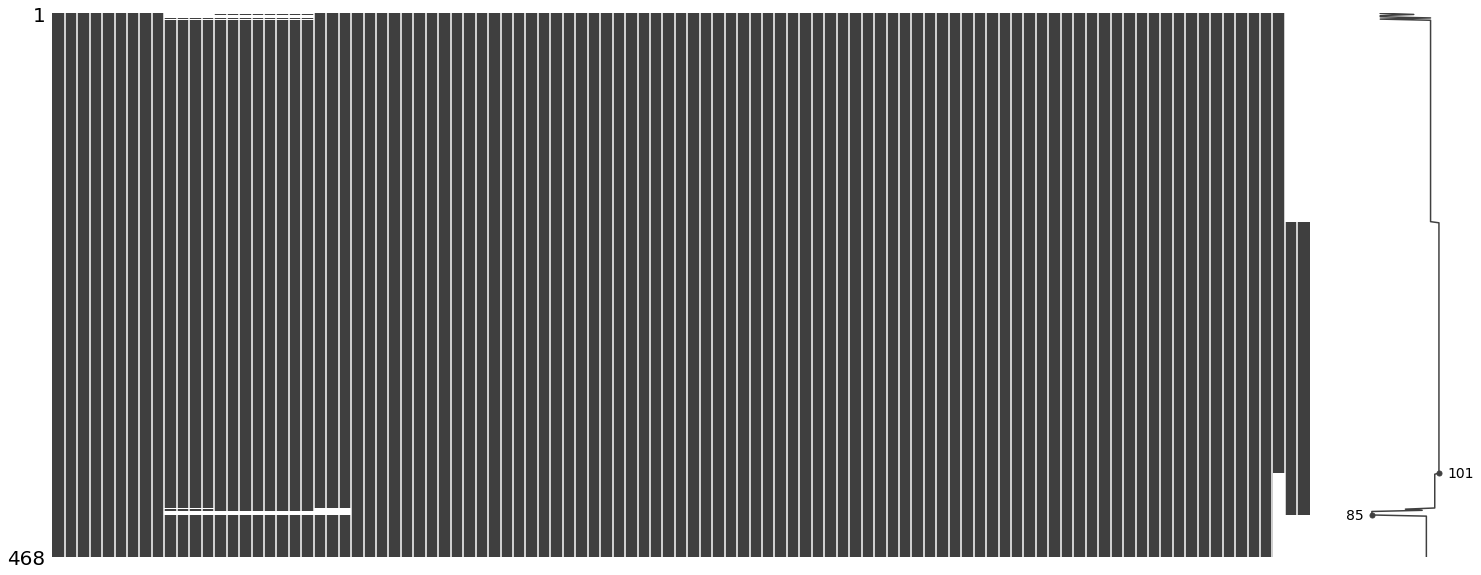

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,2.1368
1,ndmi,2.1368
2,ndwi,2.1368
3,ndbi,2.1368
4,ndvi_mean,1.7094
5,ndmi_mean,1.7094
6,ndwi_mean,1.7094
7,ndbi_mean,1.7094
8,ndvi_std,1.7094
9,ndmi_std,1.7094


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [7]:
data_p1 = []
data_p2 = []

for year in years[1:]:
    for region in nuts3_units:
        df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
        df_regional.reset_index(drop = True, inplace = True)

        df_period_1 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] == 1))].copy()
        df_period_2 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] <= 4))].copy()
        #df_period_2 = df_regional.loc[(df_regional['year'] == 2011) & (df_regional['month'] >= 2) & (df_regional['month'] <= 4)].copy()
        df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
        df_curr_year = df_regional.loc[(df_regional['year'] == year)].copy()

        x = df_curr_year['x'].mean()
        y = df_curr_year['y'].mean()

        ndvi_p1 = df_period_1['ndvi'].mean()
        ndwi_p1 = df_period_1['ndwi'].mean()
        ndmi_p1 = df_period_1['ndmi'].mean()
        ndbi_p1 = df_period_1['ndbi'].mean()

        ndvi_p2 = df_period_2['ndvi'].mean()
        ndwi_p2 = df_period_2['ndwi'].mean()
        ndmi_p2 = df_period_2['ndmi'].mean()
        ndbi_p2 = df_period_2['ndbi'].mean()
        #------------------------------------------------------
        lst_mean_p1 = df_period_1['lst'].mean()
        lst_day_mean_p1 = df_period_1['lst_day'].mean()
        lst_night_mean_p1 = df_period_1['lst_night'].mean()
        lst_min_p1 = df_period_1['monthly_lst_min'].min()
        lst_max_p1 = df_period_1['monthly_lst_min'].max()

        lst_mean_p2 = df_period_2['lst'].mean()
        lst_day_mean_p2 = df_period_2['lst_day'].mean()
        lst_night_mean_p2 = df_period_2['lst_night'].mean()
        lst_min_p2 = df_period_2['monthly_lst_min'].min()
        lst_max_p2 = df_period_2['monthly_lst_min'].max()
        #-------------------------------------------------------
        prec_mean_p1 = df_period_1['rainfall'].mean()
        prec_acc_p1 = df_period_1['monthly_acc_prec'].sum()

        prec_mean_p2 = df_period_2['rainfall'].mean()
        prec_acc_p2 = df_period_2['monthly_acc_prec'].sum()
        #-------------------------------------------------------
        mosq_mean_p1 = df_period_1['mosq_pred'].mean()
        mosq_sum_p1 = df_period_1['mosq_pred'].sum()

        mosq_mean_p2 = df_period_2['mosq_pred'].mean()
        mosq_sum_p2 = df_period_2['mosq_pred'].sum()
        #--------------------------------------------------------
        bio1 = df_prev_year.iloc[0]['bio1']
        bio2 = df_prev_year.iloc[0]['bio2']
        bio3 = df_prev_year.iloc[0]['bio3']
        bio4 = df_prev_year.iloc[0]['bio4']
        bio5 = df_prev_year.iloc[0]['bio5']
        bio6 = df_prev_year.iloc[0]['bio6']
        bio7 = df_prev_year.iloc[0]['bio7']
        bio8 = df_prev_year.iloc[0]['bio8']
        bio9 = df_prev_year.iloc[0]['bio9']
        bio10 = df_prev_year.iloc[0]['bio10']
        bio11 = df_prev_year.iloc[0]['bio11']
        bio12 = df_prev_year.iloc[0]['bio12']
        bio13 = df_prev_year.iloc[0]['bio13']
        bio14 = df_prev_year.iloc[0]['bio14']
        bio15 = df_prev_year.iloc[0]['bio15']
        bio16 = df_prev_year.iloc[0]['bio16']
        bio17 = df_prev_year.iloc[0]['bio17']
        bio18 = df_prev_year.iloc[0]['bio18']
        bio19 = df_prev_year.iloc[0]['bio19']
        #--------------------------------------------------------
        lc_prop1 = df_prev_year.iloc[0]['lc_prop1']
        lc_prop2 = df_prev_year.iloc[0]['lc_prop2']
        lc_prop3 = df_prev_year.iloc[0]['lc_prop3']
        lc_type1 = df_prev_year.iloc[0]['lc_type1']
        lc_type2 = df_prev_year.iloc[0]['lc_type2']
        lc_type3 = df_prev_year.iloc[0]['lc_type3']
        lc_type4 = df_prev_year.iloc[0]['lc_type4']
        lc_type5 = df_prev_year.iloc[0]['lc_type5']
        #--------------------------------------------------------
        distance_to_coast = df_prev_year.iloc[0]['distance_to_coast']
        distance_to_river = df_prev_year.iloc[0]['distance_to_river']
        slope_mean_1km = df_prev_year.iloc[0]['slope_mean_1km']
        aspect_mean_200m = df_prev_year.iloc[0]['aspect_mean_200m']
        elevation_mean_1km = df_prev_year.iloc[0]['elevation_mean_1km']
        hillshade_mean_1km = df_prev_year.iloc[0]['hillshade_mean_1km']
        fs_area_1km = df_prev_year.iloc[0]['fs_area_1km']
        flow_accu_200m = df_prev_year.iloc[0]['flow_accu_200m']

        distance_to_coast_std = df_prev_year.iloc[0]['distance_to_coast_std']
        distance_to_river_std = df_prev_year.iloc[0]['distance_to_river_std']
        slope_mean_1km_std = df_prev_year.iloc[0]['slope_mean_1km_std']
        aspect_mean_200m_std = df_prev_year.iloc[0]['aspect_mean_200m_std']
        elevation_mean_1km_std = df_prev_year.iloc[0]['elevation_mean_1km_std']
        hillshade_mean_1km_std = df_prev_year.iloc[0]['hillshade_mean_1km_std']
        fs_area_1km_std = df_prev_year.iloc[0]['fs_area_1km_std']
        flow_accu_200m_std = df_prev_year.iloc[0]['flow_accu_200m_std']
        #--------------------------------------------------------
        males_lt15 = df_prev_year.iloc[0]['M_Y_LT15']
        males_15t64 = df_prev_year.iloc[0]['M_Y15-64']
        males_gt65 = df_prev_year.iloc[0]['M_Y_GE65']
        males_total = df_prev_year.iloc[0]['M_TOTAL']

        females_lt15 = df_prev_year.iloc[0]['F_Y_LT15']
        females_15t64 = df_prev_year.iloc[0]['F_Y15-64']
        females_gt65 = df_prev_year.iloc[0]['F_Y_GE65']
        females_total = df_prev_year.iloc[0]['F_TOTAL']

        mio_eur = df_prev_year.iloc[0]['MIO_EUR']
        l_total = df_prev_year.iloc[0]['L_TOTAL']
        unl_total = df_prev_year.iloc[0]['UNL_TOTAL']
        #--------------------------------------------------------
        cases_total = df_curr_year['cases'].sum()
        cases_arr = df_curr_year.loc[(df_curr_year['month'] >= 5) & (df_curr_year['month'] <= 10)]['cases'].to_list()

        data_p1.append({'NUTS3_ID': region, 
                     'year': year, 
                     'x' : x,
                     'y': y,
                     'ndvi_p1': ndvi_p1,
                     'ndwi_p1': ndwi_p1,
                     'ndmi_p1': ndmi_p1,
                     'ndbi_p1': ndbi_p1,
                     'lst_mean_p1': lst_mean_p1,
                     'lst_day_mean_p1': lst_day_mean_p1,
                     'lst_night_mean_p1': lst_night_mean_p1,
                     'lst_min_p1': lst_min_p1,
                     'lst_max_p1': lst_max_p1,
                     'prec_mean_p1': prec_mean_p1,
                     'prec_acc_p1': prec_acc_p1,
                     'mosq_mean_p1': mosq_mean_p1,
                     'mosq_sum_p1': mosq_sum_p1,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })

        data_p2.append({'NUTS3_ID': region, 
                     'year': year,
                     'x' : x,
                     'y': y, 
                     'ndvi_p1': ndvi_p2,
                     'ndwi_p1': ndwi_p2,
                     'ndmi_p1': ndmi_p2,
                     'ndbi_p1': ndbi_p2,
                     'lst_mean_p1': lst_mean_p2,
                     'lst_day_mean_p1': lst_day_mean_p2,
                     'lst_night_mean_p1': lst_night_mean_p2,
                     'lst_min_p1': lst_min_p2,
                     'lst_max_p1': lst_max_p2,
                     'prec_mean_p1': prec_mean_p2,
                     'prec_acc_p1': prec_acc_p2,
                     'mosq_mean_p1': mosq_mean_p2,
                     'mosq_sum_p1': mosq_sum_p2,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })
        
p1_df = pd.DataFrame(data_p1)       
p2_df = pd.DataFrame(data_p2) 

In [8]:
p1_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL611,2011,21.719540,39.504234,0.262058,0.128474,0.344166,-0.344166,6.671742,10.158842,3.184642,-4.305779,4.520588,6.112413,559.915912,468.708189,1406.124567,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,31,20,20,12,12,4,6,7,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,14,"[0, 0, 3, 8, 3, 0]"
1,EL612,2011,22.405497,39.703383,0.227783,0.129016,0.320602,-0.320602,7.926027,12.099297,3.752758,-4.358014,5.685812,2.569974,235.698846,419.411552,1258.234657,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,31,36,30,12,12,1,6,7,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,15,"[0, 0, 4, 7, 4, 0]"
2,EL613,2011,22.869212,39.281871,0.296118,0.064122,0.301784,-0.301784,9.148190,12.441656,5.854725,-2.412083,7.174792,2.605241,240.328176,263.194444,789.583333,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,22,20,20,9,9,4,1,1,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,15287.0,68105.0,17655.0,101047.0,14898.0,67890.0,22944.0,105732.0,3102.99,NaN,NaN,1,"[0, 0, 1, 0, 0, 0]"
3,EL611,2012,21.719540,39.504234,0.256179,-0.086326,0.127228,-0.127228,4.384951,8.557831,0.212070,-8.520173,-0.665709,3.787456,350.978756,470.478662,1411.435986,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,31,20,20,12,12,4,6,7,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,17312.0,77199.0,28776.0,123287.0,16778.0,73914.0,35783.0,126475.0,2698.51,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
4,EL612,2012,22.405497,39.703383,0.235517,-0.210780,-0.004328,0.004328,5.980308,11.560791,0.399826,-7.969350,-1.456137,2.174123,201.352335,512.688327,1538.064982,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,31,36,30,12,12,1,6,7,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,23273.0,93519.0,26379.0,143171.0,22079.0,93390.0,31649.0,147118.0,4125.73,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [9]:
p2_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL611,2011,21.719540,39.504234,0.302032,0.020447,0.277693,-0.277693,7.853793,12.166534,3.541051,-4.305779,4.520588,5.247009,949.590604,424.298155,2545.788927,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,31,20,20,12,12,4,6,7,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,14,"[0, 0, 3, 8, 3, 0]"
1,EL612,2011,22.405497,39.703383,0.318170,-0.054820,0.224107,-0.224107,9.284608,14.388296,4.180920,-4.548009,5.685812,3.062571,551.235603,333.366426,2000.198556,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,31,36,30,12,12,1,6,7,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,15,"[0, 0, 4, 7, 4, 0]"
2,EL613,2011,22.869212,39.281871,0.349030,-0.043891,0.249673,-0.249673,9.831087,13.722278,5.939896,-2.412083,7.174792,3.785125,681.090318,204.300347,1225.802083,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,22,20,20,9,9,4,1,1,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,15287.0,68105.0,17655.0,101047.0,14898.0,67890.0,22944.0,105732.0,3102.99,NaN,NaN,1,"[0, 0, 1, 0, 0, 0]"
3,EL611,2012,21.719540,39.504234,0.259497,-0.055787,0.166442,-0.166442,6.760125,11.549718,1.970533,-8.520173,3.602180,4.785298,866.186877,493.200692,2959.204152,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,31,20,20,12,12,4,6,7,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,17312.0,77199.0,28776.0,123287.0,16778.0,73914.0,35783.0,126475.0,2698.51,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
4,EL612,2012,22.405497,39.703383,0.258469,-0.177634,0.056797,-0.056797,8.599924,14.890141,2.309707,-7.969350,4.188195,3.039940,548.041523,424.931408,2549.588448,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,31,36,30,12,12,1,6,7,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,23273.0,93519.0,26379.0,143171.0,22079.0,93390.0,31649.0,147118.0,4125.73,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

<AxesSubplot:>

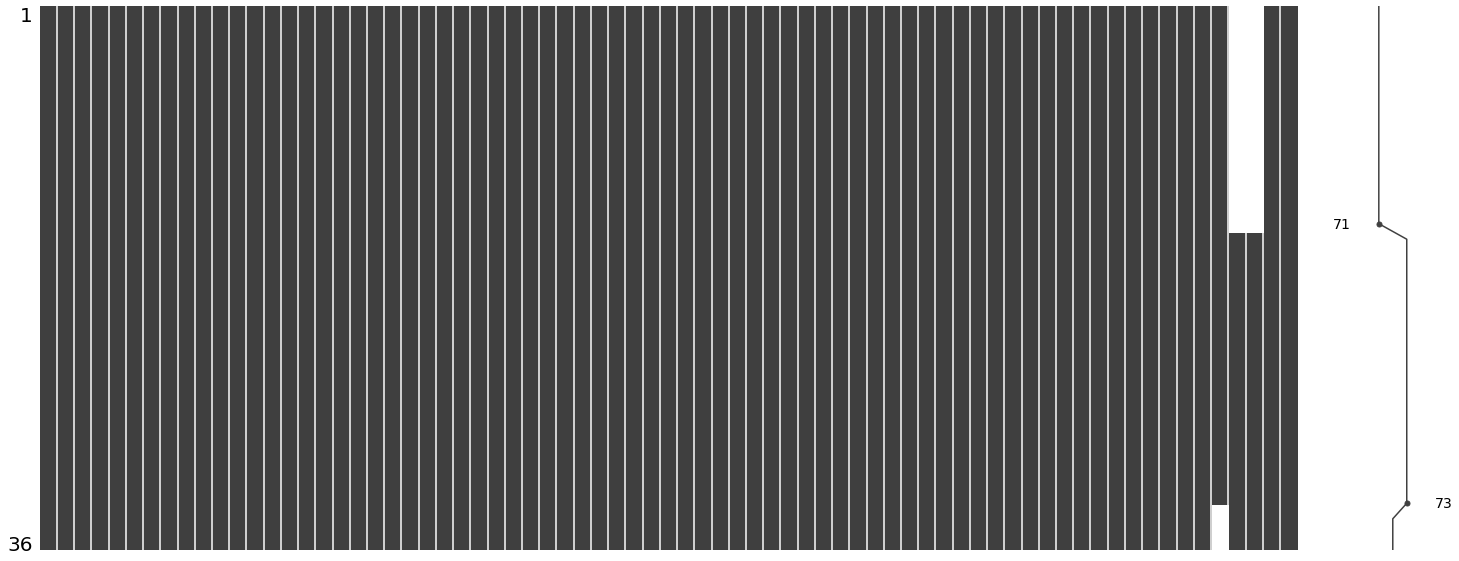

In [10]:
missingno.matrix(p1_df)

<AxesSubplot:>

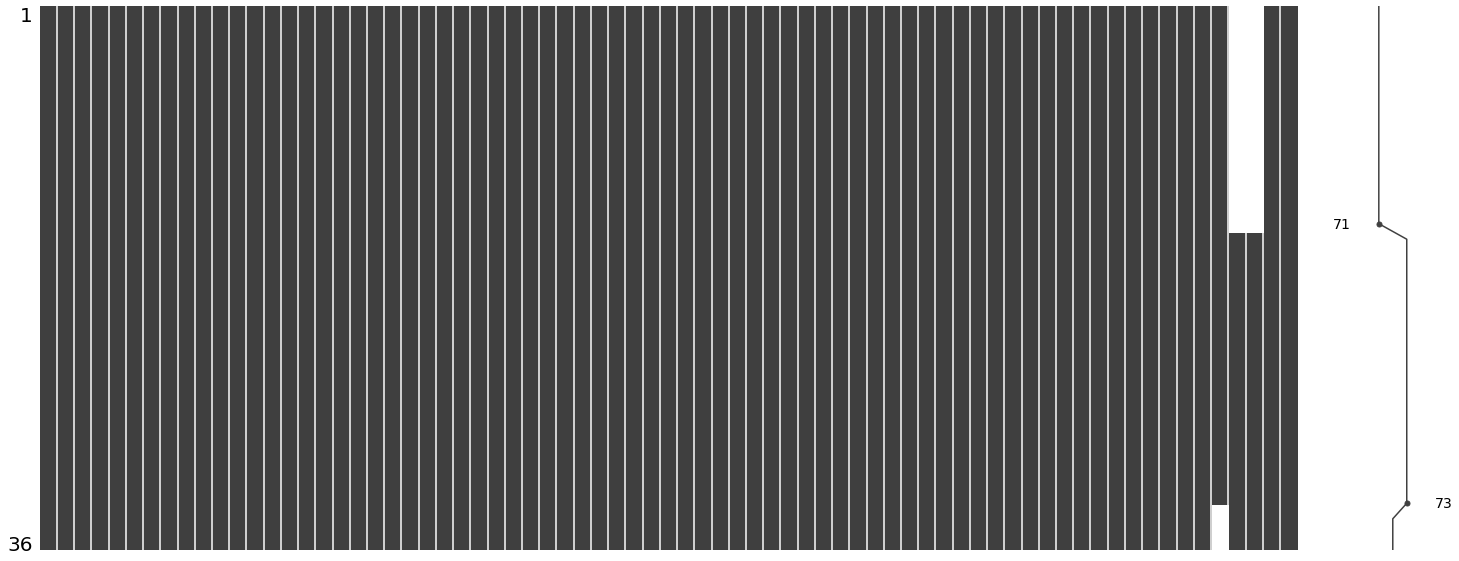

In [11]:
missingno.matrix(p2_df)

In [12]:
missing = describe_dataframe(p1_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,8.3333
1,l_total,41.6667
2,unl_total,41.6667


In [13]:
missing = describe_dataframe(p2_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,8.3333
1,l_total,41.6667
2,unl_total,41.6667


In [14]:
p1_df.cases_total.sum()

140

In [15]:
p2_df.cases_total.sum()

140

In [16]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'mio_eur']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['mio_eur']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [17]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'l_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['l_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [18]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'unl_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['unl_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

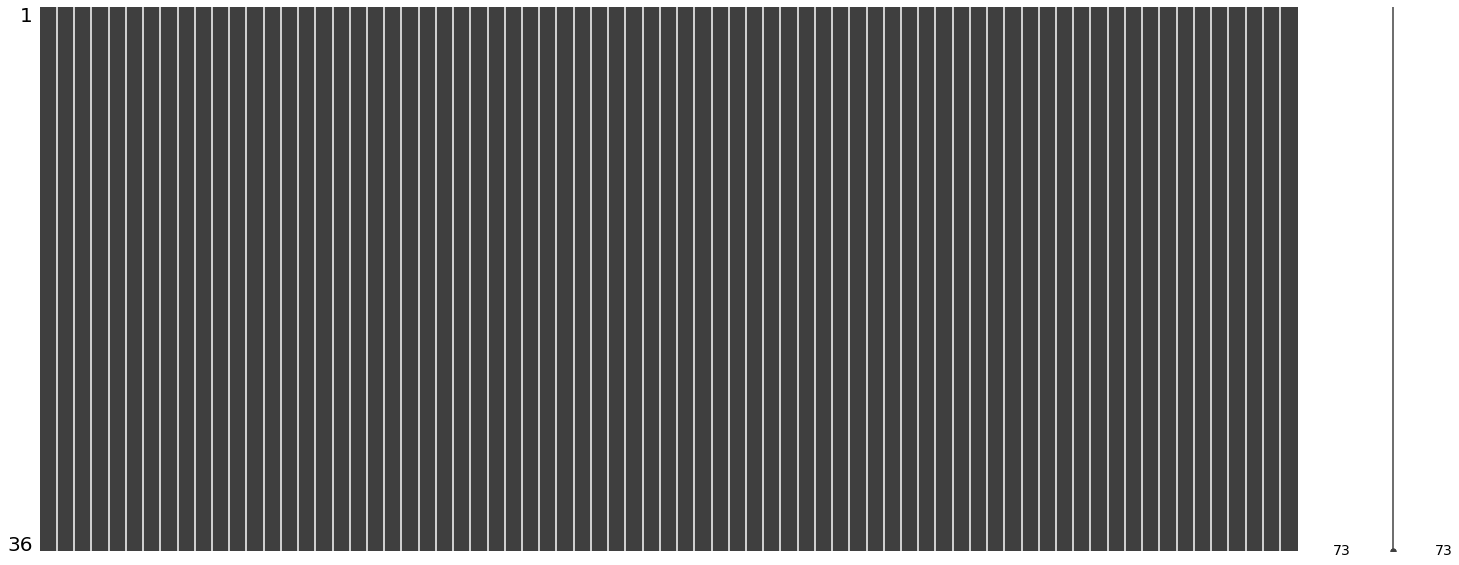

In [19]:
missingno.matrix(p1_df, label_rotation=90)

<AxesSubplot:>

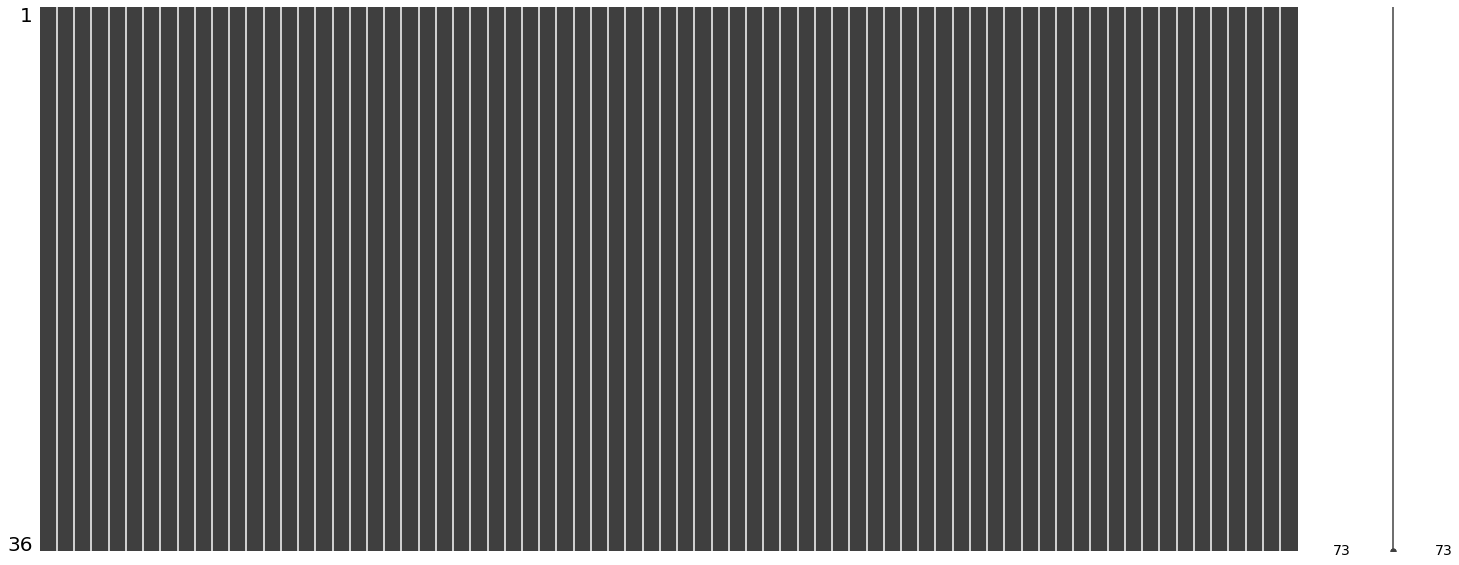

In [20]:
missingno.matrix(p2_df, label_rotation=90)

<AxesSubplot:>

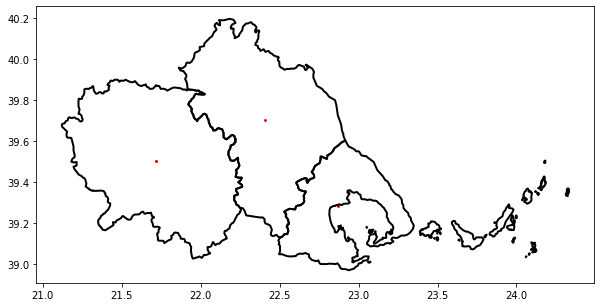

In [21]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(p1_df[['NUTS3_ID']], geometry=gpd.points_from_xy(p1_df.x, p1_df.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [22]:
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P1_2011_2022.csv", encoding = enc, index = False)
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P2_2011_2022.csv", encoding = enc, index = False)